In [1]:
# MANUFACTURING ANALYTICS PROJECT
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# STEP 1: CREATE SYNTHETIC DATASET
np.random.seed(42)

n = 1000  # number of production records

df = pd.DataFrame({
    'plant_id': np.random.choice(['Plant_A', 'Plant_B', 'Plant_C'], n),
    'product_type': np.random.choice(['Rubber', 'Polymer', 'Chemical'], n),
    'units_produced': np.random.randint(200, 1000, n),
})

In [5]:
# Create capacity and cost realistically
df['max_capacity'] = df['units_produced'] + np.random.randint(50, 300, n)

df['production_cost'] = (
    df['units_produced'] * np.random.uniform(8, 15, n) +   # variable cost
    np.random.uniform(500, 2000, n)                        # fixed cost
)

In [6]:
# STEP 2: FEATURE ENGINEERING
df['cost_per_unit'] = df['production_cost'] / df['units_produced']
df['capacity_utilization'] = df['units_produced'] / df['max_capacity']

In [7]:
# STEP 3: KPI ANALYSIS
print("Average Cost per Unit:", round(df['cost_per_unit'].mean(), 2))
print("Average Capacity Utilization:", round(df['capacity_utilization'].mean(), 2))

Average Cost per Unit: 13.97
Average Capacity Utilization: 0.76


In [8]:
# STEP 4: BOTTLENECK DETECTION
bottlenecks = df[df['capacity_utilization'] < 0.6]
print("Number of Bottlenecks:", len(bottlenecks))

Number of Bottlenecks: 104


In [9]:
# STEP 5: COST ANALYSIS
high_cost = df[df['cost_per_unit'] > df['cost_per_unit'].mean()]
print("High Cost Operations:", len(high_cost))

High Cost Operations: 493


In [10]:
# STEP 6: AGGREGATED INSIGHTS
plant_summary = df.groupby('plant_id').agg({
    'units_produced': 'sum',
    'production_cost': 'sum',
    'capacity_utilization': 'mean'
})

print("\nPlant Level Summary:\n", plant_summary)


Plant Level Summary:
           units_produced  production_cost  capacity_utilization
plant_id                                                       
Plant_A           214113     2.922070e+06              0.763281
Plant_B           194469     2.637001e+06              0.750796
Plant_C           194766     2.647747e+06              0.766354


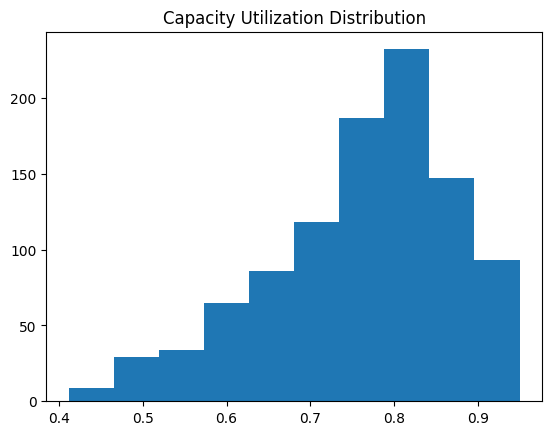

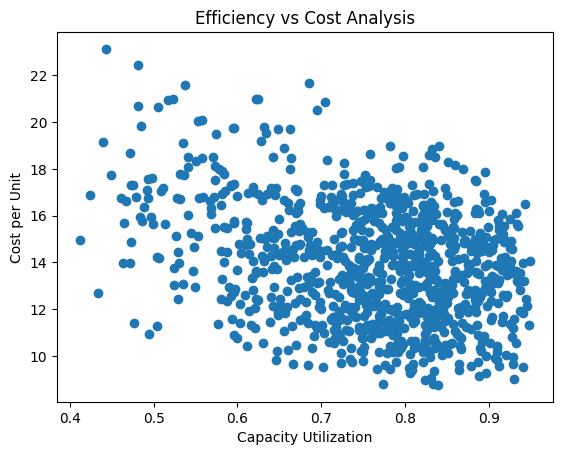

In [11]:
# STEP 7: VISUALIZATIONS
plt.hist(df['capacity_utilization'])
plt.title('Capacity Utilization Distribution')
plt.show()

plt.scatter(df['capacity_utilization'], df['cost_per_unit'])
plt.xlabel('Capacity Utilization')
plt.ylabel('Cost per Unit')
plt.title('Efficiency vs Cost Analysis')
plt.show()

In [12]:
# STEP 8: SAVE OUTPUT
df.to_csv('manufacturing_kpi_analysis.csv', index=False)